In [2]:
import numpy as np
import scipy as sp
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns
import pickle
import pingouin as pg
 

import STX3KO_analyses as stx
from STX3KO_analyses import utilities as u

from STX3KO_analyses.hse import HSE
import TwoPUtils as tpu

ko_mice = stx.ymaze_sess_deets.ko_mice
ctrl_mice = stx.ymaze_sess_deets.ctrl_mice
sparse_mice = stx.ymaze_sess_deets.sparse_mice

plt.rcParams['pdf.fonttype']=42
plt.rcParams['font.family'] ='sans-serif'
plt.rcParams['font.serif'] = 'Arial'


%matplotlib inline


In [2]:
rows = []
for cond, mice in zip(('ctrl', 'ko'),(ctrl_mice,ko_mice)):
    for mouse in mice:
        print(mouse)
        for day in range(6):
            sess = u.load_single_day(mouse, day, trial_mat_keys=['F_dff',], timeseries_keys=['F_dff',], verbose = False)
            
            rz_early = (np.argwhere(sess.trial_matrices['bin_edges'][:-1]>=sess.rzone_early['tfront'])[0], np.argwhere(sess.rzone_early['tback']<=sess.trial_matrices['bin_edges'][1:])[0] )
            rz_late = (np.argwhere(sess.trial_matrices['bin_edges'][:-1]>=sess.rzone_late['tfront'])[0], 29 )

            if sess.novel_arm == 1: 
                rz_nov = rz_late
                rz_fam = rz_early
            else: 
                rz_nov = rz_early
                rz_fam = rz_late

            for ttype in ('nov', 'fam'):
                if ttype == 'nov':
                    rz = rz_nov
                    coef = 1
                    pc_mask = sess.nov_place_cell_mask()
                else:
                    rz = rz_fam
                    coef = -1 
                    pc_mask = sess.fam_place_cell_mask()

                tmat = sess.trial_matrices['F_dff'][sess.trial_info['LR']==coef*sess.novel_arm, :, :]
                tmat[np.isnan(tmat)]=0

                cell_corrs = []
                for cell in range(tmat.shape[-1]):
                    _mat = np.corrcoef(tmat[:,:,cell])
                    _mat[np.diag_indices_from(_mat)]=np.nan
                    cell_corrs.append(np.nanmean(_mat.ravel()))
                cell_corrs = np.array(cell_corrs)

                cell_pos = np.nanargmax(np.nanmean(sess.trial_matrices['F_dff'][sess.trial_info['LR']==(coef*sess.novel_arm), :, :], axis=0),axis=0)
                
                r_mask = (cell_pos>=(rz[0]-5)) * (cell_pos<=(rz[0]+3))

                
                rows.append({'condition': cond,
                            'mouse': mouse,
                            'day': day,
                            'ttype': ttype,
                            'rzone_corr': np.nanmean(cell_corrs[r_mask*pc_mask]),
                            'nonrzone_corr': np.nanmean(cell_corrs[~r_mask]),
                            'nonrzone_pc_corr': np.nanmean(cell_corrs[(~r_mask)*pc_mask])})
                
df = pd.DataFrame(rows)

4467331.1
4467331.2
02_12_2020 YMaze_LNovel
02_12_2020 YMaze_LNovel
4467332.1
4467332.2
30_11_2020 YMaze_LNovel
30_11_2020 YMaze_LNovel
4467333.1


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")


mCherry6
mCherry7
mCherry8
mCherry9
4467975.1


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys,

4467975.2


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys,

4467975.3


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys,

4467975.4
4467975.5
Cre7
Cre9


In [9]:
# df['rzone_corr_diff'] = df['rzone_corr']-df['nonrzone_corr']
df['rzone_pc_corr_diff'] = df['rzone_corr'] - df['nonrzone_pc_corr']

<Axes: xlabel='day', ylabel='rzone_corr_diff'>

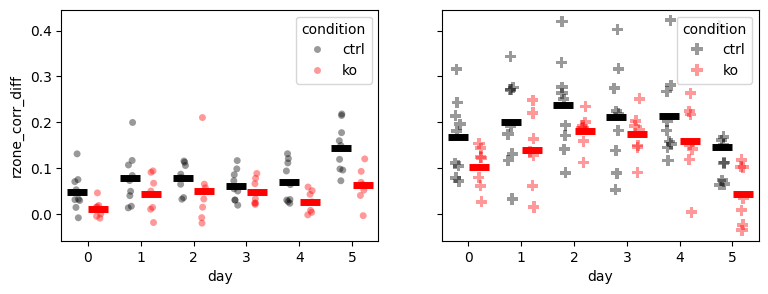

In [4]:
fig, ax = plt.subplots(1,2,figsize=[9,3], sharex=True, sharey=True)
_ = sns.stripplot(data = df.loc[df['ttype']=='fam'],
                  x='day',
                  y='rzone_corr_diff',
                  hue = 'condition',
                  hue_order= ['ctrl','ko'],
                  palette=['black','red'],
                  ax=ax[0], dodge=True, alpha=.4, s=5)

tmp_df_mu = df.groupby(['condition', 'day', 'ttype'])['rzone_corr_diff'].mean().reset_index()
sns.pointplot(data=tmp_df_mu.loc[tmp_df_mu['ttype']=='fam'],
            x='day',
            y='rzone_corr_diff',
            errorbar=None,
            hue='condition',
            hue_order = ['ctrl', 'ko'],
            dodge = .4,
            palette = ['black', 'red'],
            ax=ax[0],
            linestyles="none",
            marker="_", markersize=15, markeredgewidth=5, legend=False, alpha=1.,
            )


_ = sns.stripplot(data = df.loc[df['ttype']=='nov'],
                  x='day',
                  y='rzone_corr_diff',
                  hue = 'condition',
                  hue_order= ['ctrl','ko'],
                  palette=['black','red'],
                  ax=ax[1], dodge=True, alpha=.4, s=8, marker='P')

sns.pointplot(data=tmp_df_mu.loc[tmp_df_mu['ttype']=='nov'],
            x='day',
            y='rzone_corr_diff',
            errorbar=None,
            hue='condition',
            hue_order = ['ctrl', 'ko'],
            dodge = .4,
            palette = ['black', 'red'],
            ax=ax[1],
            linestyles="none",
            marker="_", markersize=15, markeredgewidth=5, legend=False, alpha=1.,
            )

        Source           SS  DF1  DF2           MS          F     p-unc  \
0    condition   268.698413    1   14   268.698413   6.084050  0.027162   
1        ttype  1485.125000    1   14  1485.125000  60.421618  0.000002   
2  Interaction    11.763889    1   14    11.763889   0.478608  0.500367   

        np2  eps  
0  0.302929  NaN  
1  0.811883  1.0  
2  0.033056  NaN  


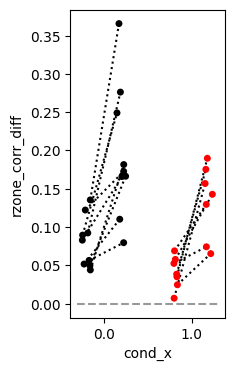

In [5]:
tmp_df = df.groupby(['condition', 'mouse', 'ttype'])['rzone_corr_diff'].mean().reset_index()
tmp_df['cond_x'] = 1.*(tmp_df['condition']=='ko')

fig, ax = plt.subplots(figsize=[2,4])
sns.stripplot(data=tmp_df.loc[tmp_df['condition']=='ctrl'],
              x='cond_x',
              y='rzone_corr_diff',
              hue='ttype',
              dodge=True,
              hue_order=['fam', 'nov'],
              palette=['black', 'black'],
              legend=False,
              ax=ax)

sns.stripplot(data=tmp_df.loc[tmp_df['condition']=='ko'],
              x='cond_x',
              y='rzone_corr_diff',
              hue='ttype',
              dodge=True,
              hue_order=['fam', 'nov'],
              palette=['red', 'red'],
              legend=False,
              ax=ax)

for d in [0,2]:
    for (x0, y0), (x1, y1) in zip(ax.collections[d].get_offsets(), ax.collections[d+1].get_offsets()):
        ax.plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)

ax.hlines(0,-.3, 1.3, linestyle='--', color='black', alpha=.4)


tmp_df['rank_rzone_corr_diff'] = tmp_df['rzone_corr_diff'].rank()
aov = pg.mixed_anova(tmp_df, dv='rank_rzone_corr_diff',
                     subject='mouse', within='ttype',
                     between='condition')
print(aov)

<Axes: xlabel='day', ylabel='rzone_corr'>

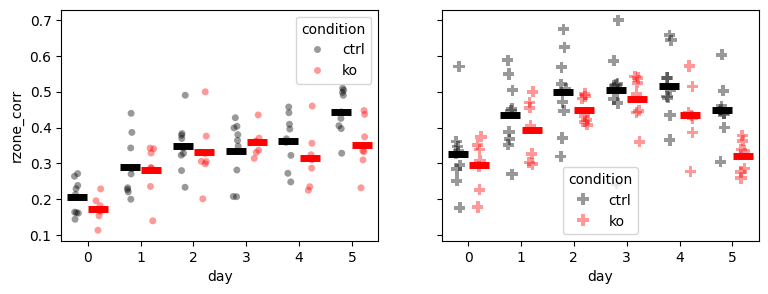

In [3]:
fig, ax = plt.subplots(1,2,figsize=[9,3], sharex=True, sharey=True)
_ = sns.stripplot(data = df.loc[df['ttype']=='fam'],
                  x='day',
                  y='rzone_corr',
                  hue = 'condition',
                  hue_order= ['ctrl','ko'],
                  palette=['black','red'],
                  ax=ax[0], dodge=True, alpha=.4, s=5)

tmp_df_mu = df.groupby(['condition', 'day', 'ttype'])['rzone_corr'].mean().reset_index()
sns.pointplot(data=tmp_df_mu.loc[tmp_df_mu['ttype']=='fam'],
            x='day',
            y='rzone_corr',
            errorbar=None,
            hue='condition',
            hue_order = ['ctrl', 'ko'],
            dodge = .4,
            palette = ['black', 'red'],
            ax=ax[0],
            linestyles="none",
            marker="_", markersize=15, markeredgewidth=5, legend=False, alpha=1.,
            )


_ = sns.stripplot(data = df.loc[df['ttype']=='nov'],
                  x='day',
                  y='rzone_corr',
                  hue = 'condition',
                  hue_order= ['ctrl','ko'],
                  palette=['black','red'],
                  ax=ax[1], dodge=True, alpha=.4, s=8, marker='P')

sns.pointplot(data=tmp_df_mu.loc[tmp_df_mu['ttype']=='nov'],
            x='day',
            y='rzone_corr',
            errorbar=None,
            hue='condition',
            hue_order = ['ctrl', 'ko'],
            dodge = .4,
            palette = ['black', 'red'],
            ax=ax[1],
            linestyles="none",
            marker="_", markersize=15, markeredgewidth=5, legend=False, alpha=1.,
            )

In [14]:
aov = pg.mixed_anova(data=df.loc[(df['day']<6) * (df['ttype']=='nov')],
                      dv='rzone_corr', subject='mouse', within='day', between='condition')
print(aov)

res = pg.pairwise_tests(data=df.loc[(df['day']<6) * (df['ttype']=='nov')],
                        dv='rzone_corr', subject='mouse', within='day', between='condition',
                        parametric=False, padjust='holm')
res

        Source        SS  DF1  DF2        MS          F         p-unc  \
0    condition  0.078354    1   14  0.078354   2.242293  1.564855e-01   
1          day  0.399469    5   70  0.079894  25.289179  1.791420e-14   
2  Interaction  0.034142    5   70  0.006828   2.161402  6.817361e-02   

        np2       eps  
0  0.138053       NaN  
1  0.643668  0.709584  
2  0.133739       NaN  


,Contrast,day,A,B,Paired,Parametric,U-val,W-val,alternative,p-unc,p-corr,p-adjust,hedges
0,day,-,0,1,True,False,NaN,0.0,two-sided,0.000031,0.000458,holm,-1.107449
1,day,-,0,2,True,False,NaN,0.0,two-sided,0.000031,0.000458,holm,-1.782572
2,day,-,0,3,True,False,NaN,0.0,two-sided,0.000031,0.000458,holm,-1.848508
3,day,-,0,4,True,False,NaN,1.0,two-sided,0.000061,0.000732,holm,-1.704884
4,day,-,0,5,True,False,NaN,18.0,two-sided,0.007629,0.053406,holm,-0.841897
5,day,-,1,2,True,False,NaN,21.0,two-sided,0.013092,0.078552,holm,-0.653055
6,day,-,1,3,True,False,NaN,17.0,two-sided,0.006287,0.050293,holm,-0.779070
7,day,-,1,4,True,False,NaN,21.0,two-sided,0.013092,0.078552,holm,-0.643398
8,day,-,1,5,True,False,NaN,51.0,two-sided,0.403748,1.000000,holm,0.264105
9,day,-,2,3,True,False,NaN,45.0,two-sided,0.252228,1.000000,holm,-0.163095


In [5]:
import statsmodels.formula.api as smf
mdl = smf.mixedlm('rzone_corr ~ C(condition)*C(ttype) + C(condition)*C(day)', df, groups=df['mouse'])
result = mdl.fit()
result.summary()


/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


<class 'statsmodels.iolib.summary2.Summary'>
"""
                    Mixed Linear Model Regression Results
=============================================================================
Model:                   MixedLM        Dependent Variable:        rzone_corr
No. Observations:        192            Method:                    REML      
No. Groups:              16             Scale:                     0.0041    
Min. group size:         12             Log-Likelihood:            200.3363  
Max. group size:         12             Converged:                 Yes       
Mean group size:         12.0                                                
-----------------------------------------------------------------------------
                                   Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------------
Intercept                           0.204    0.025  8.268 0.000  0.156  0.252
C(condition)[T.ko]                 -0.017    0.037 -0.448 0.654 -0.090  0.056
C(ttype)[T.nov]                     0.124    0.012 10.071 0.000  0.100  0.149
C(day)[T.1]                         0.096    0.021  4.487 0.000  0.054  0.138
C(day)[T.2]                         0.158    0.021  7.370 0.000  0.116  0.200
C(day)[T.3]                         0.153    0.021  7.156 0.000  0.111  0.195
C(day)[T.4]                         0.174    0.021  8.136 0.000  0.132  0.216
C(day)[T.5]                         0.181    0.021  8.437 0.000  0.139  0.222
C(condition)[T.ko]:C(ttype)[T.nov] -0.031    0.019 -1.642 0.101 -0.067  0.006
C(condition)[T.ko]:C(day)[T.1]      0.007    0.032  0.211 0.833 -0.057  0.070
C(condition)[T.ko]:C(day)[T.2]     -0.003    0.032 -0.078 0.938 -0.066  0.061
C(condition)[T.ko]:C(day)[T.3]      0.031    0.032  0.958 0.338 -0.032  0.094
C(condition)[T.ko]:C(day)[T.4]     -0.034    0.032 -1.038 0.299 -0.097  0.030
C(condition)[T.ko]:C(day)[T.5]     -0.079    0.032 -2.433 0.015 -0.142 -0.015
Group Var                           0.003    0.021                           
=============================================================================

"""

<Axes: xlabel='day', ylabel='nonrzone_pc_corr'>

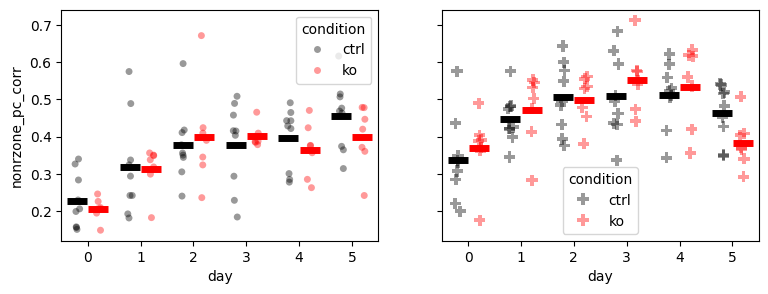

In [6]:
fig, ax = plt.subplots(1,2,figsize=[9,3], sharex=True, sharey=True)
_ = sns.stripplot(data = df.loc[df['ttype']=='fam'],
                  x='day',
                  y='nonrzone_pc_corr',
                  hue = 'condition',
                  hue_order= ['ctrl','ko'],
                  palette=['black','red'],
                  ax=ax[0], dodge=True, alpha=.4, s=5)

tmp_df_mu = df.groupby(['condition', 'day', 'ttype'])['nonrzone_pc_corr'].mean().reset_index()
sns.pointplot(data=tmp_df_mu.loc[tmp_df_mu['ttype']=='fam'],
            x='day',
            y='nonrzone_pc_corr',
            errorbar=None,
            hue='condition',
            hue_order = ['ctrl', 'ko'],
            dodge = .4,
            palette = ['black', 'red'],
            ax=ax[0],
            linestyles="none",
            marker="_", markersize=15, markeredgewidth=5, legend=False, alpha=1.,
            )


_ = sns.stripplot(data = df.loc[df['ttype']=='nov'],
                  x='day',
                  y='nonrzone_pc_corr',
                  hue = 'condition',
                  hue_order= ['ctrl','ko'],
                  palette=['black','red'],
                  ax=ax[1], dodge=True, alpha=.4, s=8, marker='P')

sns.pointplot(data=tmp_df_mu.loc[tmp_df_mu['ttype']=='nov'],
            x='day',
            y='nonrzone_pc_corr',
            errorbar=None,
            hue='condition',
            hue_order = ['ctrl', 'ko'],
            dodge = .4,
            palette = ['black', 'red'],
            ax=ax[1],
            linestyles="none",
            marker="_", markersize=15, markeredgewidth=5, legend=False, alpha=1.,
            )

In [7]:
import statsmodels.formula.api as smf
mdl = smf.mixedlm('nonrzone_pc_corr ~ C(condition)*C(ttype) + C(condition)*C(day)', df, groups=df['mouse'])
result = mdl.fit()
result.summary()

/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


<class 'statsmodels.iolib.summary2.Summary'>
"""
                    Mixed Linear Model Regression Results
=============================================================================
Model:                 MixedLM      Dependent Variable:      nonrzone_pc_corr
No. Observations:      192          Method:                  REML            
No. Groups:            16           Scale:                   0.0048          
Min. group size:       12           Log-Likelihood:          185.4853        
Max. group size:       12           Converged:               Yes             
Mean group size:       12.0                                                  
-----------------------------------------------------------------------------
                                   Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------------
Intercept                           0.231    0.027  8.430 0.000  0.178  0.285
C(condition)[T.ko]                 -0.004    0.041 -0.107 0.915 -0.086  0.077
C(ttype)[T.nov]                     0.104    0.013  7.733 0.000  0.077  0.130
C(day)[T.1]                         0.101    0.023  4.337 0.000  0.055  0.146
C(day)[T.2]                         0.159    0.023  6.842 0.000  0.113  0.204
C(day)[T.3]                         0.160    0.023  6.907 0.000  0.115  0.206
C(day)[T.4]                         0.170    0.023  7.347 0.000  0.125  0.216
C(day)[T.5]                         0.177    0.023  7.621 0.000  0.131  0.222
C(condition)[T.ko]:C(ttype)[T.nov]  0.017    0.020  0.860 0.390 -0.022  0.057
C(condition)[T.ko]:C(day)[T.1]      0.005    0.035  0.139 0.890 -0.064  0.074
C(condition)[T.ko]:C(day)[T.2]      0.004    0.035  0.105 0.917 -0.065  0.072
C(condition)[T.ko]:C(day)[T.3]      0.030    0.035  0.855 0.392 -0.039  0.099
C(condition)[T.ko]:C(day)[T.4]     -0.008    0.035 -0.236 0.813 -0.077  0.060
C(condition)[T.ko]:C(day)[T.5]     -0.072    0.035 -2.056 0.040 -0.141 -0.003
Group Var                           0.004    0.025                           
=============================================================================

"""

<Axes: xlabel='day', ylabel='rzone_pc_corr_diff'>

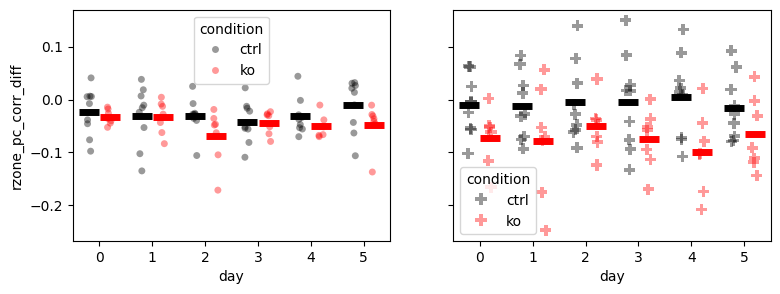

In [10]:
fig, ax = plt.subplots(1,2,figsize=[9,3], sharex=True, sharey=True)
_ = sns.stripplot(data = df.loc[df['ttype']=='fam'],
                  x='day',
                  y='rzone_pc_corr_diff',
                  hue = 'condition',
                  hue_order= ['ctrl','ko'],
                  palette=['black','red'],
                  ax=ax[0], dodge=True, alpha=.4, s=5)

tmp_df_mu = df.groupby(['condition', 'day', 'ttype'])['rzone_pc_corr_diff'].mean().reset_index()
sns.pointplot(data=tmp_df_mu.loc[tmp_df_mu['ttype']=='fam'],
            x='day',
            y='rzone_pc_corr_diff',
            errorbar=None,
            hue='condition',
            hue_order = ['ctrl', 'ko'],
            dodge = .4,
            palette = ['black', 'red'],
            ax=ax[0],
            linestyles="none",
            marker="_", markersize=15, markeredgewidth=5, legend=False, alpha=1.,
            )


_ = sns.stripplot(data = df.loc[df['ttype']=='nov'],
                  x='day',
                  y='rzone_pc_corr_diff',
                  hue = 'condition',
                  hue_order= ['ctrl','ko'],
                  palette=['black','red'],
                  ax=ax[1], dodge=True, alpha=.4, s=8, marker='P')

sns.pointplot(data=tmp_df_mu.loc[tmp_df_mu['ttype']=='nov'],
            x='day',
            y='rzone_pc_corr_diff',
            errorbar=None,
            hue='condition',
            hue_order = ['ctrl', 'ko'],
            dodge = .4,
            palette = ['black', 'red'],
            ax=ax[1],
            linestyles="none",
            marker="_", markersize=15, markeredgewidth=5, legend=False, alpha=1.,
            )

        Source            SS  DF1  DF2            MS         F     p-unc  \
0    condition  1.400660e-02    1   14  1.400660e-02  8.237143  0.012352   
1        ttype  1.156779e-07    1   14  1.156779e-07  0.000043  0.994879   
2  Interaction  4.551426e-03    1   14  4.551426e-03  1.679850  0.215904   

        np2  eps  
0  0.370423  NaN  
1  0.000003  1.0  
2  0.107134  NaN  


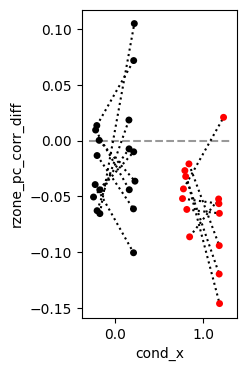

In [11]:
tmp_df = df.groupby(['condition', 'mouse', 'ttype'])['rzone_pc_corr_diff'].mean().reset_index()
tmp_df['cond_x'] = 1.*(tmp_df['condition']=='ko')

fig, ax = plt.subplots(figsize=[2,4])
sns.stripplot(data=tmp_df.loc[tmp_df['condition']=='ctrl'],
              x='cond_x',
              y='rzone_pc_corr_diff',
              hue='ttype',
              dodge=True,
              hue_order=['fam', 'nov'],
              palette=['black', 'black'],
              legend=False,
              ax=ax)

sns.stripplot(data=tmp_df.loc[tmp_df['condition']=='ko'],
              x='cond_x',
              y='rzone_pc_corr_diff',
              hue='ttype',
              dodge=True,
              hue_order=['fam', 'nov'],
              palette=['red', 'red'],
              legend=False,
              ax=ax)

for d in [0,2]:
    for (x0, y0), (x1, y1) in zip(ax.collections[d].get_offsets(), ax.collections[d+1].get_offsets()):
        ax.plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)

ax.hlines(0,-.3, 1.3, linestyle='--', color='black', alpha=.4)


tmp_df['rank_rzone_pc_corr_diff'] = tmp_df['rzone_pc_corr_diff'].rank()
aov = pg.mixed_anova(tmp_df, dv='rzone_pc_corr_diff',
                     subject='mouse', within='ttype',
                     between='condition')
print(aov)

In [20]:
rows = []

for mouse in sparse_mice:
    print(mouse)
    for day in range(6):
        if mouse == 'SparseKO_09' and day ==2:
            continue
        for chan in ('channel_0','channel_1'):
            sess = u.load_single_day(mouse, day, trial_mat_keys=[f'{chan}_F_dff',], timeseries_keys=[f'{chan}_F_dff',], verbose = False)
            
            rz_early = (np.argwhere(sess.trial_matrices['bin_edges'][:-1]>=sess.rzone_early['tfront'])[0], np.argwhere(sess.rzone_early['tback']<=sess.trial_matrices['bin_edges'][1:])[0] )
            rz_late = (np.argwhere(sess.trial_matrices['bin_edges'][:-1]>=sess.rzone_late['tfront'])[0], 29 )

            if sess.novel_arm == 1: 
                rz_nov = rz_late
                rz_fam = rz_early
            else: 
                rz_nov = rz_early
                rz_fam = rz_late

            pc_mask = sess.nov_place_cell_mask(mux=True, chan=chan) + sess.fam_place_cell_mask(mux=True, chan=chan)
            # place cell peak

            tmat_nov = sess.trial_matrices[f'{chan}_F_dff'][sess.trial_info["LR"]==sess.novel_arm,:,:][:,:,pc_mask]
            maxpos_nov = np.nanargmax(np.nanmean(tmat_nov,axis=0), axis=0)
            rz_cell_nov = (maxpos_nov>=(rz_nov[0]-6)) * (maxpos_nov<=(rz_nov[0]+2))

            tmat_fam = sess.trial_matrices[f'{chan}_F_dff'][sess.trial_info["LR"]!=sess.novel_arm,:,:][:,:,pc_mask]
            maxpos_fam = np.nanargmax(np.nanmean(tmat_fam,axis=0), axis=0)
            rz_cell_fam = (maxpos_nov>=(rz_fam[0]-6)) * (maxpos_nov<=(rz_fam[0]+2))

            r_cell_mask = rz_cell_fam * rz_cell_nov

            cell_corrs = {'nov': [], 'fam': []}
            for cell in range(tmat_nov.shape[-1]):
                _mat = np.corrcoef(tmat_nov[:,:,cell])
                _mat[np.diag_indices_from(_mat)]=np.nan
                cell_corrs['nov'].append(np.nanmean(_mat.ravel()))

                _mat = np.corrcoef(tmat_fam[:,:,cell])
                _mat[np.diag_indices_from(_mat)]=np.nan
                cell_corrs['fam'].append(np.nanmean(_mat.ravel()))
            cell_corrs = {k:np.array(v) for k,v in cell_corrs.items()}

            for ttype in ('nov', 'fam'):
                rows.append({'chan': chan,
                            'mouse': mouse,
                            'day': day,
                            'ttype': ttype,
                            'rzone_corr': np.nanmean(cell_corrs[ttype][r_cell_mask]),
                            'nonrzone_corr': np.nanmean(cell_corrs[ttype][~r_cell_mask]),
                            })
                
df = pd.DataFrame(rows)

SparseKO_02
SparseKO_06
SparseKO_08


/tmp/ipykernel_293685/1629368961.py:50: RuntimeWarning: Mean of empty slice
  'rzone_corr': np.nanmean(cell_corrs[ttype][r_cell_mask]),


SparseKO_10
SparseKO_11
SparseKO_13


/tmp/ipykernel_293685/1629368961.py:25: RuntimeWarning: Mean of empty slice
  maxpos_nov = np.nanargmax(np.nanmean(tmat_nov,axis=0), axis=0)
/tmp/ipykernel_293685/1629368961.py:38: RuntimeWarning: Mean of empty slice
  cell_corrs['nov'].append(np.nanmean(_mat.ravel()))
/tmp/ipykernel_293685/1629368961.py:50: RuntimeWarning: Mean of empty slice
  'rzone_corr': np.nanmean(cell_corrs[ttype][r_cell_mask]),
/tmp/ipykernel_293685/1629368961.py:51: RuntimeWarning: Mean of empty slice
  'nonrzone_corr': np.nanmean(cell_corrs[ttype][~r_cell_mask]),
/tmp/ipykernel_293685/1629368961.py:38: RuntimeWarning: Mean of empty slice
  cell_corrs['nov'].append(np.nanmean(_mat.ravel()))
/tmp/ipykernel_293685/1629368961.py:50: RuntimeWarning: Mean of empty slice
  'rzone_corr': np.nanmean(cell_corrs[ttype][r_cell_mask]),
/tmp/ipykernel_293685/1629368961.py:51: RuntimeWarning: Mean of empty slice
  'nonrzone_corr': np.nanmean(cell_corrs[ttype][~r_cell_mask]),
/tmp/ipykernel_293685/1629368961.py:38: RuntimeWa

SparseKO_09


/tmp/ipykernel_293685/1629368961.py:50: RuntimeWarning: Mean of empty slice
  'rzone_corr': np.nanmean(cell_corrs[ttype][r_cell_mask]),


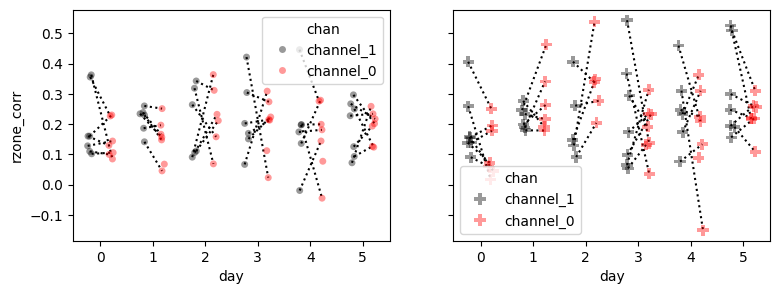

In [21]:
fig, ax = plt.subplots(1,2,figsize=[9,3], sharex=True, sharey=True)
_ = sns.stripplot(data = df.loc[df['ttype']=='fam'],
                  x='day',
                  y='rzone_corr',
                  hue = 'chan',
                  hue_order= ['channel_1','channel_0'],
                  palette=['black','red'],
                  ax=ax[0], dodge=True, alpha=.4, s=5)

for d in range(0,12,2):
    for (x0, y0), (x1, y1) in zip(ax[0].collections[d].get_offsets(), ax[0].collections[d+1].get_offsets()):
        ax[0].plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)

_ = sns.stripplot(data = df.loc[df['ttype']=='nov'],
                  x='day',
                  y='rzone_corr',
                  hue = 'chan',
                  hue_order= ['channel_1','channel_0'],
                  palette=['black','red'],
                  ax=ax[1], dodge=True, alpha=.4, s=8, marker='P')
for d in range(0,12,2):
    for (x0, y0), (x1, y1) in zip(ax[1].collections[d].get_offsets(), ax[1].collections[d+1].get_offsets()):
        ax[1].plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)



In [16]:
aov = pg.rm_anova(data = df.loc[(df['ttype']=='fam') ], dv='rzone_corr',
                  subject='mouse', within=['day', 'chan'])
print(aov)

       Source        SS  ddof1  ddof2        MS         F     p-unc  \
0         day  0.025293      5     25  0.005059  4.815674  0.003212   
1        chan  0.005057      1      5  0.005057  1.811016  0.236185   
2  day * chan  0.003606      5     25  0.000721  0.503533  0.770699   

   p-GG-corr       ng2       eps  
0   0.024733  0.182687  0.479911  
1   0.236185  0.042776  1.000000  
2   0.621938  0.030882  0.407474  


/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrameGroupBy.diff with axis=1 is deprecated and will be removed in a future version. Operate on the un-grouped DataFrame instead
  data.groupby(level=1, axis=1, observed=True, group_keys=False)


In [15]:
#  load place fields

In [10]:
sess = u.single_mouse_concat_sessions(ctrl_mice[0], np.arange(6), trial_mat_keys=['F_dff'], timeseries_keys=['F_dff'])

29_11_2020 YMaze_LNovel
30_11_2020 YMaze_LNovel
01_12_2020 YMaze_LNovel
02_12_2020 YMaze_LNovel
03_12_2020 YMaze_LNovel
04_12_2020 YMaze_LNovel


In [ ]:
sess.nov_place_cell_mask()

np.True_

In [17]:

rows = []
for cond, mice in zip(('ctrl', 'ko'), (ctrl_mice, ko_mice)):
    for mouse in mice:
        print(mouse)
        sess = u.single_mouse_concat_sessions(mouse, np.arange(6), trial_mat_keys=['F_dff'], timeseries_keys=['F_dff'])
        rz_early = (np.argwhere(sess.trial_matrices['bin_edges'][:-1]>=sess.rzone_early['tfront'])[0], np.argwhere(sess.rzone_early['tback']<=sess.trial_matrices['bin_edges'][1:])[0] )
        rz_late = (np.argwhere(sess.trial_matrices['bin_edges'][:-1]>=sess.rzone_late['tfront'])[0], 29 )

        if sess.novel_arm == 1: 
            rz_nov = rz_late
            rz_fam = rz_early
        else: 
            rz_nov = rz_early
            rz_fam = rz_late

        nov_mask= sess.trial_info['LR']==sess.novel_arm
        for day in range(5):

            day_mask = sess.trial_info['sess_num']==day
            pc_mask = sess.place_cell_info[-1]['masks'][day] + sess.place_cell_info[1]['masks'][day]
            # place cell peak

            tmat_nov = np.nanmean(sess.trial_matrices['F_dff'][nov_mask*day_mask,:,:][:,:,pc_mask], axis=0)
            maxpos_nov = np.nanargmax(tmat_nov, axis=0)
            rel_pos_nov = maxpos_nov-rz_nov[0]
            rz_cell_nov = (maxpos_nov>=(rz_nov[0]-5)) * (maxpos_nov<=(rz_nov[0]+1))

            tmat_fam = np.nanmean(sess.trial_matrices['F_dff'][~nov_mask*day_mask,:,:][:,:,pc_mask], axis=0)
            maxpos_fam = np.nanargmax(tmat_fam, axis=0)
            rel_pos_fam = maxpos_fam - rz_fam[0]
            rz_cell_fam = (maxpos_fam>=(rz_fam[0]-5)) * (maxpos_fam<=(rz_fam[0]+1))

            r_cell_mask = rz_cell_fam * rz_cell_nov
            o_cell_mask = (rz_cell_fam + rz_cell_nov) * (~r_cell_mask)

            for next_day in range(day+1,6):
                next_day_mask = sess.trial_info['sess_num']==next_day
                for ttype in ('nov', 'fam'):
                    if ttype == 'nov':
                        n_mask = nov_mask
                        rz = rz_nov
                        day_mat = tmat_nov
                        day_rel_pos  =rel_pos_nov
                    else:
                        n_mask = ~nov_mask
                        rz = rz_fam
                        day_mat = tmat_fam
                        day_rel_pos = rel_pos_nov
                    
                    next_day_tmat = np.nanmean(sess.trial_matrices['F_dff'][n_mask*next_day_mask,:,:][:,:,pc_mask],axis=0)
                    next_day_pos = np.nanargmax(next_day_tmat,axis=0)
                    next_day_rel_pos = next_day_pos-rz[0]
                    
                    next_day_corr = np.zeros([next_day_tmat.shape[1],])
                    for cell in range(next_day_tmat.shape[1]):
                        r, _ = sp.stats.pearsonr(day_mat[:,cell], next_day_tmat[:,cell])
                        next_day_corr[cell]=r

                    for (d, nd, ndc) in zip(day_rel_pos[r_cell_mask], 
                                            next_day_rel_pos[r_cell_mask],
                                            next_day_corr[r_cell_mask]):
                        rows.append({'cond': cond,
                                    'mouse': mouse, 
                                    'day': day,
                                    'next_day': next_day,
                                    'ttype': ttype,
                                    'reward_cell': True,
                                    'day_rel_pos': d,
                                    'next_day_rel_pos': nd,
                                    'next_day_corr': ndc})
                        
                    for (d, nd, ndc) in zip(day_rel_pos[o_cell_mask], 
                                            next_day_rel_pos[o_cell_mask],
                                            next_day_corr[o_cell_mask]):
                        rows.append({'cond': cond,
                                    'mouse': mouse, 
                                    'day': day,
                                    'next_day': next_day,
                                    'ttype': ttype,
                                    'reward_cell': False,
                                    'day_rel_pos': d,
                                    'next_day_rel_pos': nd,
                                    'next_day_corr': ndc})

df = pd.DataFrame(rows)
df['pos_diff']= np.abs(df['next_day_rel_pos']-df['day_rel_pos'])


4467331.1
29_11_2020 YMaze_LNovel
30_11_2020 YMaze_LNovel
01_12_2020 YMaze_LNovel
02_12_2020 YMaze_LNovel
03_12_2020 YMaze_LNovel
04_12_2020 YMaze_LNovel
4467331.2
29_11_2020 YMaze_LNovel
30_11_2020 YMaze_LNovel
01_12_2020 YMaze_LNovel
02_12_2020 YMaze_LNovel
02_12_2020 YMaze_LNovel
03_12_2020 YMaze_LNovel
04_12_2020 YMaze_LNovel
4467332.1
29_11_2020 YMaze_LNovel
30_11_2020 YMaze_LNovel
01_12_2020 YMaze_LNovel
02_12_2020 YMaze_LNovel
03_12_2020 YMaze_LNovel
04_12_2020 YMaze_LNovel
4467332.2
29_11_2020 YMaze_LNovel
30_11_2020 YMaze_LNovel
30_11_2020 YMaze_LNovel
01_12_2020 YMaze_LNovel
02_12_2020 YMaze_LNovel
03_12_2020 YMaze_LNovel
04_12_2020 YMaze_LNovel
4467333.1
29_11_2020 YMaze_LNovel
30_11_2020 YMaze_LNovel
01_12_2020 YMaze_LNovel
02_12_2020 YMaze_LNovel
03_12_2020 YMaze_LNovel


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")


05_12_2020 YMaze_LNovel
mCherry6
14_10_2021 YMaze_LNovel
15_10_2021 YMaze_LNovel
16_10_2021 YMaze_LNovel
17_10_2021 YMaze_LNovel
18_10_2021 YMaze_LNovel
19_10_2021 YMaze_LNovel
mCherry7
14_10_2021 YMaze_LNovel
15_10_2021 YMaze_LNovel
16_10_2021 YMaze_LNovel
17_10_2021 YMaze_LNovel
18_10_2021 YMaze_LNovel
19_10_2021 YMaze_LNovel
mCherry8
14_10_2021 YMaze_LNovel
15_10_2021 YMaze_LNovel
16_10_2021 YMaze_LNovel
17_10_2021 YMaze_LNovel
18_10_2021 YMaze_LNovel
20_10_2021 YMaze_LNovel
mCherry9
15_10_2021 YMaze_LNovel
16_10_2021 YMaze_LNovel
17_10_2021 YMaze_LNovel
19_10_2021 YMaze_LNovel
20_10_2021 YMaze_LNovel
21_10_2021 YMaze_LNovel
4467975.1


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")


28_09_2020 YMaze_LNovel


...

01_10_2020 YMaze_LNovel


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")


02_10_2020 YMaze_LNovel


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")


03_10_2020 YMaze_LNovel
4467975.4
28_09_2020 YMaze_LNovel
29_09_2020 YMaze_LNovel
30_09_2020 YMaze_LNovel
01_10_2020 YMaze_LNovel
02_10_2020 YMaze_LNovel
03_10_2020 YMaze_LNovel
4467975.5
28_09_2020 YMaze_LNovel
29_09_2020 YMaze_LNovel
30_09_2020 YMaze_LNovel
01_10_2020 YMaze_LNovel
02_10_2020 YMaze_LNovel
03_10_2020 YMaze_LNovel
Cre7
18_10_2021 YMaze_LNovel
19_10_2021 YMaze_LNovel
20_10_2021 YMaze_LNovel
21_10_2021 YMaze_LNovel
22_10_2021 YMaze_LNovel
23_10_2021 YMaze_LNovel
Cre9
18_10_2021 YMaze_LNovel
19_10_2021 YMaze_LNovel
20_10_2021 YMaze_LNovel
21_10_2021 YMaze_LNovel
23_10_2021 YMaze_LNovel
23_10_2021 YMaze_LNovel


In [18]:
df.head()

,cond,mouse,day,next_day,ttype,reward_cell,day_rel_pos,next_day_rel_pos,next_day_corr,pos_diff
0,ctrl,4467331.1,0,1,nov,True,0,-1,0.917341,1
1,ctrl,4467331.1,0,1,nov,True,-2,-5,0.625234,3
2,ctrl,4467331.1,0,1,nov,True,0,-1,0.934109,1
3,ctrl,4467331.1,0,1,nov,True,-1,-1,0.359037,0
4,ctrl,4467331.1,0,1,nov,True,1,-2,0.320347,3


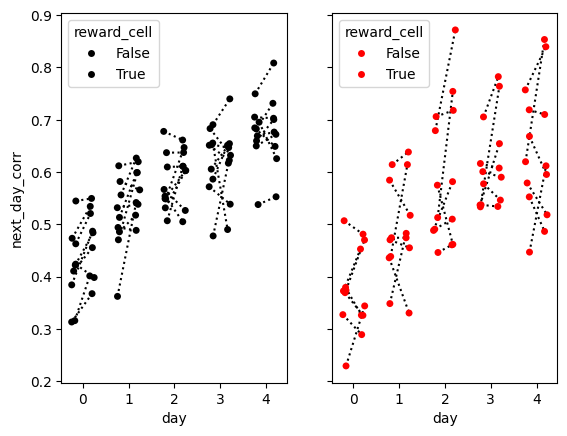

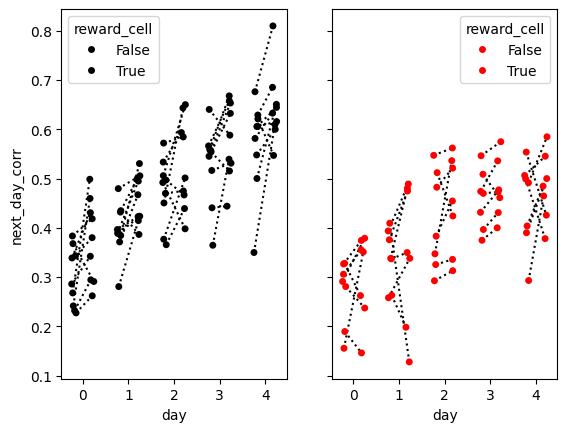

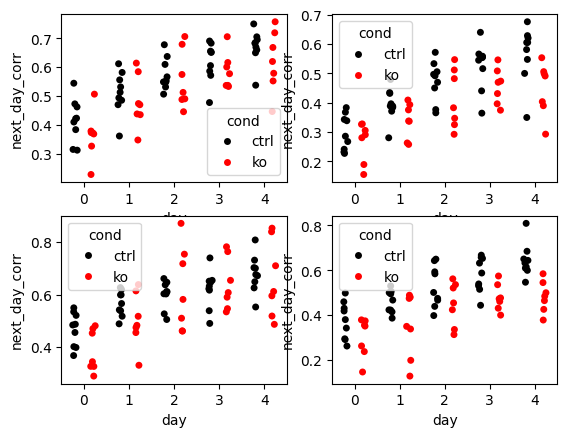

In [24]:
fig, ax = plt.subplots(1,2, sharex=True, sharey=True)

tmp_df = df.groupby(['cond', 'mouse', 'day', 'ttype', 'reward_cell'])['next_day_corr'].mean().reset_index()
_ = sns.stripplot(data=tmp_df.loc[(tmp_df['ttype']=='fam') * (tmp_df['cond']=='ctrl')],
                  x='day',
                  y='next_day_corr',
                  hue='reward_cell',
                  hue_order=[False, True],
                  palette=['black', 'black'],
                  dodge=True, ax=ax[0]
                  )
for d in range(0,10,2):
    for (x0, y0), (x1, y1) in zip(ax[0].collections[d].get_offsets(), ax[0].collections[d+1].get_offsets()):
        ax[0].plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)

_ = sns.stripplot(data=tmp_df.loc[(tmp_df['ttype']=='fam') * (tmp_df['cond']=='ko')],
                  x='day',
                  y='next_day_corr',
                  hue='reward_cell',
                  hue_order=[False, True],
                  palette=['red', 'red'],
                  dodge=True, ax=ax[1]
                  )
for d in range(0,10,2):
    for (x0, y0), (x1, y1) in zip(ax[1].collections[d].get_offsets(), ax[1].collections[d+1].get_offsets()):
        ax[1].plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)



fig, ax = plt.subplots(1,2, sharex=True, sharey=True)

tmp_df = df.groupby(['cond', 'mouse', 'day', 'ttype', 'reward_cell'])['next_day_corr'].mean().reset_index()
_ = sns.stripplot(data=tmp_df.loc[(tmp_df['ttype']=='nov') * (tmp_df['cond']=='ctrl')],
                  x='day',
                  y='next_day_corr',
                  hue='reward_cell',
                  hue_order=[False, True],
                  palette=['black', 'black'],
                  dodge=True, ax=ax[0]
                  )
for d in range(0,10,2):
    for (x0, y0), (x1, y1) in zip(ax[0].collections[d].get_offsets(), ax[0].collections[d+1].get_offsets()):
        ax[0].plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)

_ = sns.stripplot(data=tmp_df.loc[(tmp_df['ttype']=='nov') * (tmp_df['cond']=='ko')],
                  x='day',
                  y='next_day_corr',
                  hue='reward_cell',
                  hue_order=[False, True],
                  palette=['red', 'red'],
                  dodge=True, ax=ax[1]
                  )
for d in range(0,10,2):
    for (x0, y0), (x1, y1) in zip(ax[1].collections[d].get_offsets(), ax[1].collections[d+1].get_offsets()):
        ax[1].plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)

fig, ax = plt.subplots(2,2)
_ = sns.stripplot(data=tmp_df.loc[(tmp_df['ttype']=='fam') * (tmp_df['reward_cell']==False)],
                  x='day',
                  y='next_day_corr',
                  hue='cond',
                  hue_order=['ctrl', 'ko'],
                  palette=['black', 'red'],
                  dodge=True, ax=ax[0,0]
                  )

_ = sns.stripplot(data=tmp_df.loc[(tmp_df['ttype']=='nov') * (tmp_df['reward_cell']==False)],
                  x='day',
                  y='next_day_corr',
                  hue='cond',
                  hue_order=['ctrl', 'ko'],
                  palette=['black', 'red'],
                  dodge=True, ax=ax[0,1]
                  )
_ = sns.stripplot(data=tmp_df.loc[(tmp_df['ttype']=='fam') * (tmp_df['reward_cell']==True)],
                  x='day',
                  y='next_day_corr',
                  hue='cond',
                  hue_order=['ctrl', 'ko'],
                  palette=['black', 'red'],
                  dodge=True, ax=ax[1,0]
                  )

_ = sns.stripplot(data=tmp_df.loc[(tmp_df['ttype']=='nov') * (tmp_df['reward_cell']==True)],
                  x='day',
                  y='next_day_corr',
                  hue='cond',
                  hue_order=['ctrl', 'ko'],
                  palette=['black', 'red'],
                  dodge=True, ax=ax[1,1]
                  )


57.0 0.005244755244755245


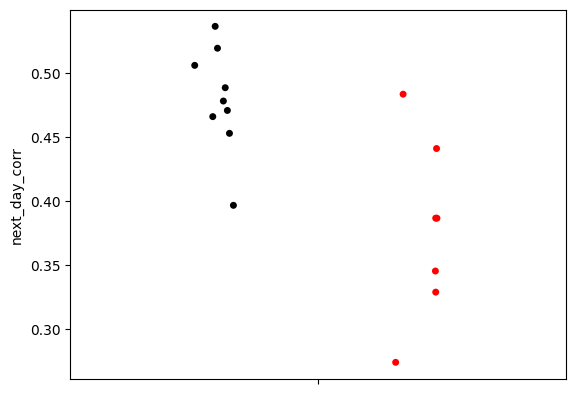

In [34]:
tmp_df = df.groupby(['cond', 'mouse', 'ttype', 'reward_cell'])['next_day_corr'].mean().reset_index()
fig, ax = plt.subplots()
sns.stripplot(data = tmp_df.loc[(tmp_df['ttype']=='nov') * (tmp_df['reward_cell']==True)],
              y='next_day_corr', hue='cond',hue_order=['ctrl','ko'],
              palette=['black','red'],ax=ax, legend=False, dodge=True)

mask = (tmp_df['ttype']=='nov') * (tmp_df['reward_cell']==True)
r,p = sp.stats.mannwhitneyu(tmp_df.loc[mask*(tmp_df['cond']=='ctrl'), 'next_day_corr'],
                            tmp_df.loc[mask*(tmp_df['cond']=='ko'), 'next_day_corr'])
print(r,p)

In [36]:
aov = pg.rm_anova(data=df.loc[df['cond']=='ctrl'], subject='mouse',
                  within=['reward_cell'], dv = 'next_day_corr')
aov

,Source,ddof1,ddof2,F,p-unc,ng2,eps
0,reward_cell,1,8,25.982029,0.000933,0.31803,1.0


In [38]:
aov = pg.rm_anova(data=df.loc[df['cond']=='ko'], subject='mouse',
                  within=[ 'reward_cell'], dv = 'next_day_corr')
aov

,Source,ddof1,ddof2,F,p-unc,ng2,eps
0,reward_cell,1,6,2.775558,0.146764,0.082996,1.0


In [ ]:
aov = pg.mixed_anova(data = df.loc[(df['ttype']=='nov')], subject='mouse',
                     within='reward_cell', between='cond', dv='next_day_corr')
aov


,Source,SS,DF1,DF2,MS,F,p-unc,np2,eps
0,cond,0.048562,1,14,0.048562,10.436659,0.006042,0.427090,NaN
1,reward_cell,0.022275,1,14,0.022275,20.286600,0.000495,0.591677,1.0
2,Interaction,0.004053,1,14,0.004053,3.691436,0.075290,0.208657,NaN


In [ ]:
aov = pg.mixed_anova(data = df.loc[(df['ttype']=='nov')*(df['reward_cell']==True)], subject='mouse',
                     within='day', between='cond', dv='next_day_corr')
aov

,Source,SS,DF1,DF2,MS,F,p-unc,np2,eps
0,cond,0.012645,1,14,0.012645,0.479466,4.999893e-01,0.033114,NaN
1,day,0.570371,4,56,0.142593,34.315246,1.807572e-14,0.710236,0.718201
2,Interaction,0.035306,4,56,0.008826,2.124091,8.980847e-02,0.131734,NaN


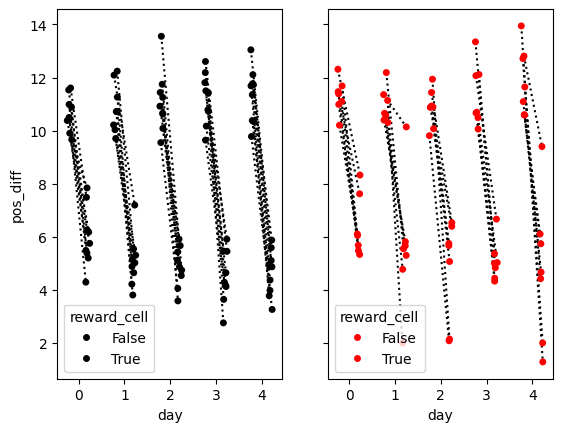

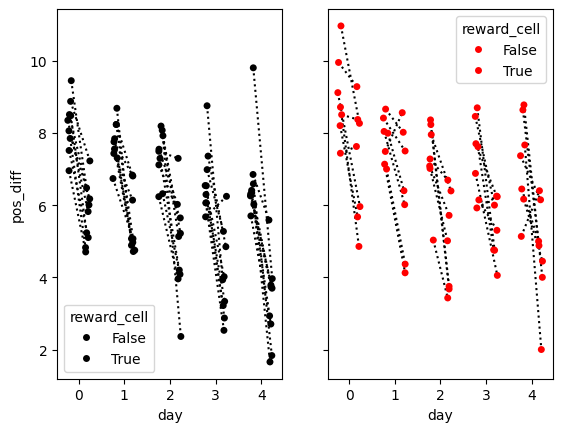

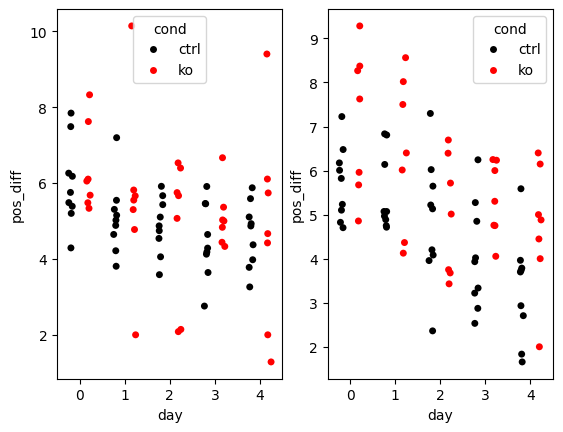

In [20]:
fig, ax = plt.subplots(1,2, sharex=True, sharey=True)

tmp_df = df.groupby(['cond', 'mouse', 'day', 'ttype', 'reward_cell'])['pos_diff'].mean().reset_index()
_ = sns.stripplot(data=tmp_df.loc[(tmp_df['ttype']=='fam') * (tmp_df['cond']=='ctrl')],
                  x='day',
                  y='pos_diff',
                  hue='reward_cell',
                  hue_order=[False, True],
                  palette=['black', 'black'],
                  dodge=True, ax=ax[0]
                  )
for d in range(0,10,2):
    for (x0, y0), (x1, y1) in zip(ax[0].collections[d].get_offsets(), ax[0].collections[d+1].get_offsets()):
        ax[0].plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)

_ = sns.stripplot(data=tmp_df.loc[(tmp_df['ttype']=='fam') * (tmp_df['cond']=='ko')],
                  x='day',
                  y='pos_diff',
                  hue='reward_cell',
                  hue_order=[False, True],
                  palette=['red', 'red'],
                  dodge=True, ax=ax[1]
                  )
for d in range(0,10,2):
    for (x0, y0), (x1, y1) in zip(ax[1].collections[d].get_offsets(), ax[1].collections[d+1].get_offsets()):
        ax[1].plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)



fig, ax = plt.subplots(1,2, sharex=True, sharey=True)

tmp_df = df.groupby(['cond', 'mouse', 'day', 'ttype', 'reward_cell'])['pos_diff'].mean().reset_index()
_ = sns.stripplot(data=tmp_df.loc[(tmp_df['ttype']=='nov') * (tmp_df['cond']=='ctrl')],
                  x='day',
                  y='pos_diff',
                  hue='reward_cell',
                  hue_order=[False, True],
                  palette=['black', 'black'],
                  dodge=True, ax=ax[0]
                  )
for d in range(0,10,2):
    for (x0, y0), (x1, y1) in zip(ax[0].collections[d].get_offsets(), ax[0].collections[d+1].get_offsets()):
        ax[0].plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)

_ = sns.stripplot(data=tmp_df.loc[(tmp_df['ttype']=='nov') * (tmp_df['cond']=='ko')],
                  x='day',
                  y='pos_diff',
                  hue='reward_cell',
                  hue_order=[False, True],
                  palette=['red', 'red'],
                  dodge=True, ax=ax[1]
                  )
for d in range(0,10,2):
    for (x0, y0), (x1, y1) in zip(ax[1].collections[d].get_offsets(), ax[1].collections[d+1].get_offsets()):
        ax[1].plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)

fig, ax = plt.subplots(1,2)
_ = sns.stripplot(data=tmp_df.loc[(tmp_df['ttype']=='fam') * (tmp_df['reward_cell']==True)],
                  x='day',
                  y='pos_diff',
                  hue='cond',
                  hue_order=['ctrl', 'ko'],
                  palette=['black', 'red'],
                  dodge=True, ax=ax[0]
                  )

_ = sns.stripplot(data=tmp_df.loc[(tmp_df['ttype']=='nov') * (tmp_df['reward_cell']==True)],
                  x='day',
                  y='pos_diff',
                  hue='cond',
                  hue_order=['ctrl', 'ko'],
                  palette=['black', 'red'],
                  dodge=True, ax=ax[1]
                  )


In [30]:
aov = pg.mixed_anova(data = df.loc[(df['ttype']=='fam')*(df['reward_cell']==True)], subject='mouse',
                     within='day', between='cond', dv='pos_diff')
aov

,Source,SS,DF1,DF2,MS,F,p-unc,p-GG-corr,np2,eps,sphericity,W-spher,p-spher
0,cond,1.997566,1,14,1.997566,0.353979,0.561363,NaN,0.024661,NaN,NaN,NaN,NaN
1,day,23.596273,4,56,5.899068,4.829967,0.002035,0.008147,0.256504,0.594922,False,0.14564,0.002326
2,Interaction,1.188128,4,56,0.297032,0.243200,0.912589,NaN,0.017075,NaN,NaN,NaN,NaN


<Axes: xlabel='day', ylabel='next_day_corr'>

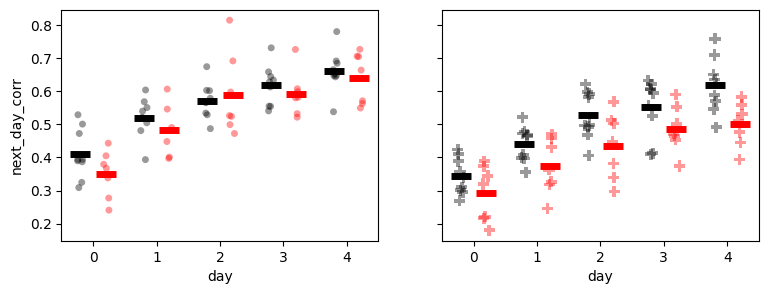

In [23]:
fig, ax = plt.subplots(1,2, figsize=[9,3], sharex=True, sharey=True)
mask = (df['ttype']=='fam') * ((df['day_rel_pos']>=-5) * (df['day_rel_pos']<=2))
tmp_df = df.loc[mask].groupby(['cond', 'mouse', 'day', 'ttype'])['next_day_corr'].mean().reset_index()
sns.stripplot(data=tmp_df,
             x='day',
             y='next_day_corr',
             hue='cond',
             hue_order=['ctrl','ko'],
             palette=['black', 'red'],
             ax=ax[0], dodge=True, legend = False, alpha=.4,
             )

tmp_df_mu = tmp_df.groupby(['cond', 'day'])['next_day_corr'].mean().reset_index()
sns.pointplot(data=tmp_df_mu,
            x='day',
            y='next_day_corr',
            errorbar=None,
            hue='cond',
            hue_order = ['ctrl', 'ko'],
            dodge = .4,
            palette = ['black', 'red'],
            ax=ax[0],
            linestyles="none",
            marker="_", markersize=15, markeredgewidth=5, legend=False, alpha=1.,
            )

mask = (df['ttype']=='nov') * ((df['day_rel_pos']>=-5) * (df['day_rel_pos']<=2))
tmp_df = df.loc[mask].groupby(['cond', 'mouse', 'day', 'ttype'])['next_day_corr'].mean().reset_index()
sns.stripplot(data=tmp_df,
             x='day',
             y='next_day_corr',
             hue='cond',
             hue_order=['ctrl','ko'],
             palette=['black', 'red'],
             ax=ax[1], dodge=True, marker='P', s=8, legend=False, alpha=.4,
             )

tmp_df_mu = tmp_df.groupby(['cond', 'day'])['next_day_corr'].mean().reset_index()
sns.pointplot(data=tmp_df_mu,
            x='day',
            y='next_day_corr',
            errorbar=None,
            hue='cond',
            hue_order = ['ctrl', 'ko'],
            dodge = .4,
            palette = ['black', 'red'],
            ax=ax[1],
            linestyles="none",
            marker="_", markersize=15, markeredgewidth=5, legend=False, alpha=1.,
            )



In [28]:
df['rank_next_day_corr'] = df['next_day_corr'].rank()
aov = pg.mixed_anova(data=df.loc[(df['ttype']=='nov') * ((df['day_rel_pos']>=-5) * (df['day_rel_pos']<=2)) ], 
                     dv = 'rank_next_day_corr',
                     between = 'cond',
                     within= 'day',
                     subject='mouse')
aov

,Source,SS,DF1,DF2,MS,F,p-unc,p-GG-corr,np2,eps,sphericity,W-spher,p-spher
0,cond,4.056918e+08,1,14,4.056918e+08,13.068486,2.813297e-03,NaN,0.482793,NaN,NaN,NaN,NaN
1,day,3.390292e+08,4,56,8.475730e+07,14.700808,2.860403e-08,0.000004,0.512209,0.628028,False,0.21523,0.015202
2,Interaction,1.754714e+07,4,56,4.386785e+06,0.760870,5.551713e-01,NaN,0.051546,NaN,NaN,NaN,NaN
